# Gerar e visualizar máscaras positivas

Este notebook recebe o **ID de uma imagem**, lê o vetor corrigido no QGIS, rasteriza esse vetor usando exatamente a grade espacial da imagem original e salva a máscara final.

Ao final, são mostrados:

1. imagem RGB;
2. máscara final;
3. máscara sobreposta à imagem.

A única célula que precisa ser alterada no uso normal é a célula **Escolher imagem**.


## 1. Bibliotecas


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.features import rasterize


## 2. Caminhos do projeto


In [2]:
# Notebook localizado dentro da pasta notebooks/
PASTA_IMAGENS = Path("../data/segmentacao/images")
PASTA_VETORES = Path("../data/segmentacao/vetor_edit")
PASTA_MASCARAS_FINAIS = Path("../data/segmentacao/masks_final")

PASTA_MASCARAS_FINAIS.mkdir(
    parents=True,
    exist_ok=True
)

print("Pasta de imagens:", PASTA_IMAGENS.resolve())
print("Pasta de vetores:", PASTA_VETORES.resolve())
print("Pasta de máscaras finais:", PASTA_MASCARAS_FINAIS.resolve())


Pasta de imagens: /home/gabriel-david/Banco_de_areia/data/segmentacao/images
Pasta de vetores: /home/gabriel-david/Banco_de_areia/data/segmentacao/vetor_edit
Pasta de máscaras finais: /home/gabriel-david/Banco_de_areia/data/segmentacao/masks_final


## 3. Funções auxiliares


In [3]:
def normalizar(banda):
    """Normaliza uma banda usando os percentis 2 e 98."""

    banda = banda.astype(np.float32)

    minimo = np.nanpercentile(
        banda,
        2
    )

    maximo = np.nanpercentile(
        banda,
        98
    )

    if np.isclose(maximo, minimo):
        return np.zeros_like(
            banda,
            dtype=np.float32
        )

    banda = np.clip(
        banda,
        minimo,
        maximo
    )

    return (
        (banda - minimo)
        / (maximo - minimo)
    )


def carregar_rgb(caminho_imagem):
    """Lê B02, B03 e B04 e monta uma composição RGB."""

    with rasterio.open(caminho_imagem) as src:
        b02 = src.read(1)
        b03 = src.read(2)
        b04 = src.read(3)

    rgb = np.dstack([
        normalizar(b04),
        normalizar(b03),
        normalizar(b02)
    ])

    return rgb


## 4. Função para rasterizar o vetor

O vetor corrigido é transformado em uma máscara com:

- `0` = fundo;
- `255` = banco de areia.

A imagem original é usada como referência para manter **shape, resolução, transform e CRS**.


In [4]:
def gerar_mascara_final(
    id_imagem,
    all_touched=True
):
    id_imagem = str(id_imagem)

    caminho_imagem = (
        PASTA_IMAGENS
        / f"{id_imagem}.tif"
    )

    caminho_vetor = (
        PASTA_VETORES
        / f"{id_imagem}.gpkg"
    )

    caminho_saida = (
        PASTA_MASCARAS_FINAIS
        / f"{id_imagem}.tif"
    )

    # -----------------------------
    # Verificações
    # -----------------------------
    if not caminho_imagem.exists():
        raise FileNotFoundError(
            "Imagem não encontrada:\n"
            f"{caminho_imagem.resolve()}"
        )

    if not caminho_vetor.exists():
        raise FileNotFoundError(
            "Vetor corrigido não encontrado:\n"
            f"{caminho_vetor.resolve()}\n\n"
            "Confirme se o arquivo do QGIS possui "
            "o mesmo ID da imagem."
        )

    # -----------------------------
    # Ler vetor corrigido
    # -----------------------------
    gdf = gpd.read_file(
        caminho_vetor
    )

    if gdf.empty:
        raise ValueError(
            f"O vetor {caminho_vetor.name} está vazio."
        )

    gdf = gdf[
        gdf.geometry.notna()
        & ~gdf.geometry.is_empty
    ].copy()

    if gdf.empty:
        raise ValueError(
            "O arquivo vetorial não possui "
            "geometrias válidas para rasterizar."
        )

    # -----------------------------
    # Ler grade da imagem original
    # -----------------------------
    with rasterio.open(
        caminho_imagem
    ) as src:

        perfil = src.profile.copy()
        altura = src.height
        largura = src.width
        transform = src.transform
        crs = src.crs

    # -----------------------------
    # Garantir mesmo CRS
    # -----------------------------
    if gdf.crs is None:
        raise ValueError(
            "O vetor não possui CRS definido."
        )

    if gdf.crs != crs:
        gdf = gdf.to_crs(
            crs
        )

    # -----------------------------
    # Rasterizar
    # -----------------------------
    mascara = rasterize(
        [
            (geometria, 255)
            for geometria in gdf.geometry
        ],
        out_shape=(
            altura,
            largura
        ),
        transform=transform,
        fill=0,
        dtype=np.uint8,
        all_touched=all_touched
    )

    # -----------------------------
    # Salvar GeoTIFF final
    # -----------------------------
    perfil.update(
        count=1,
        dtype="uint8",
        nodata=0
    )

    with rasterio.open(
        caminho_saida,
        "w",
        **perfil
    ) as dst:

        dst.write(
            mascara,
            1
        )

    return {
        "id": id_imagem,
        "imagem": caminho_imagem,
        "vetor": caminho_vetor,
        "saida": caminho_saida,
        "mascara": mascara
    }


## 5. Função de visualização


In [5]:
def visualizar_resultado(
    caminho_imagem,
    mascara,
    titulo=""
):
    rgb = carregar_rgb(
        caminho_imagem
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 6)
    )

    # -----------------------------
    # Imagem original
    # -----------------------------
    axes[0].imshow(
        rgb
    )

    axes[0].set_title(
        "Imagem original"
    )

    # -----------------------------
    # Ground truth
    # -----------------------------
    axes[1].imshow(
        mascara,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axes[1].set_title(
        "Ground truth"
    )

    # -----------------------------
    # Sobreposição
    # -----------------------------
    axes[2].imshow(
        rgb
    )

    # Fundo 0 fica transparente.
    mascara_overlay = np.ma.masked_where(
        mascara == 0,
        mascara
    )

    axes[2].imshow(
        mascara_overlay,
        cmap="Reds",
        alpha=0.55,
        vmin=0,
        vmax=255
    )

    axes[2].set_title(
        "Sobreposição"
    )

    for ax in axes:
        ax.axis(
            "off"
        )

    if titulo:
        fig.suptitle(
            titulo,
            fontsize=16
        )

    plt.tight_layout()
    plt.show()


## 6. Escolher imagem

**Altere apenas o ID abaixo.**

O notebook procurará automaticamente:

- `images/ID.tif`
- `vetor_edit/ID.gpkg`

e salvará:

- `masks_final/ID.tif`


In [43]:
ID_IMAGEM = 1737


## 7. Gerar máscara e visualizar


Imagem: ../data/segmentacao/images/1737.tif
Vetor: ../data/segmentacao/vetor_edit/1737.gpkg
Máscara salva em: ../data/segmentacao/masks_final/1737.tif

Shape: (130, 130)
Tipo: uint8
Valores únicos: [  0 255]
Pixels positivos: 289
Percentual positivo: 1.710%


/home/gabriel-david/miniconda3/envs/banco_areia/lib/python3.11/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in '1737.gpkg': 'banco_areia' (default), '1737__banco_areia'. Specify layer parameter to avoid this warning.
  result = read_func(


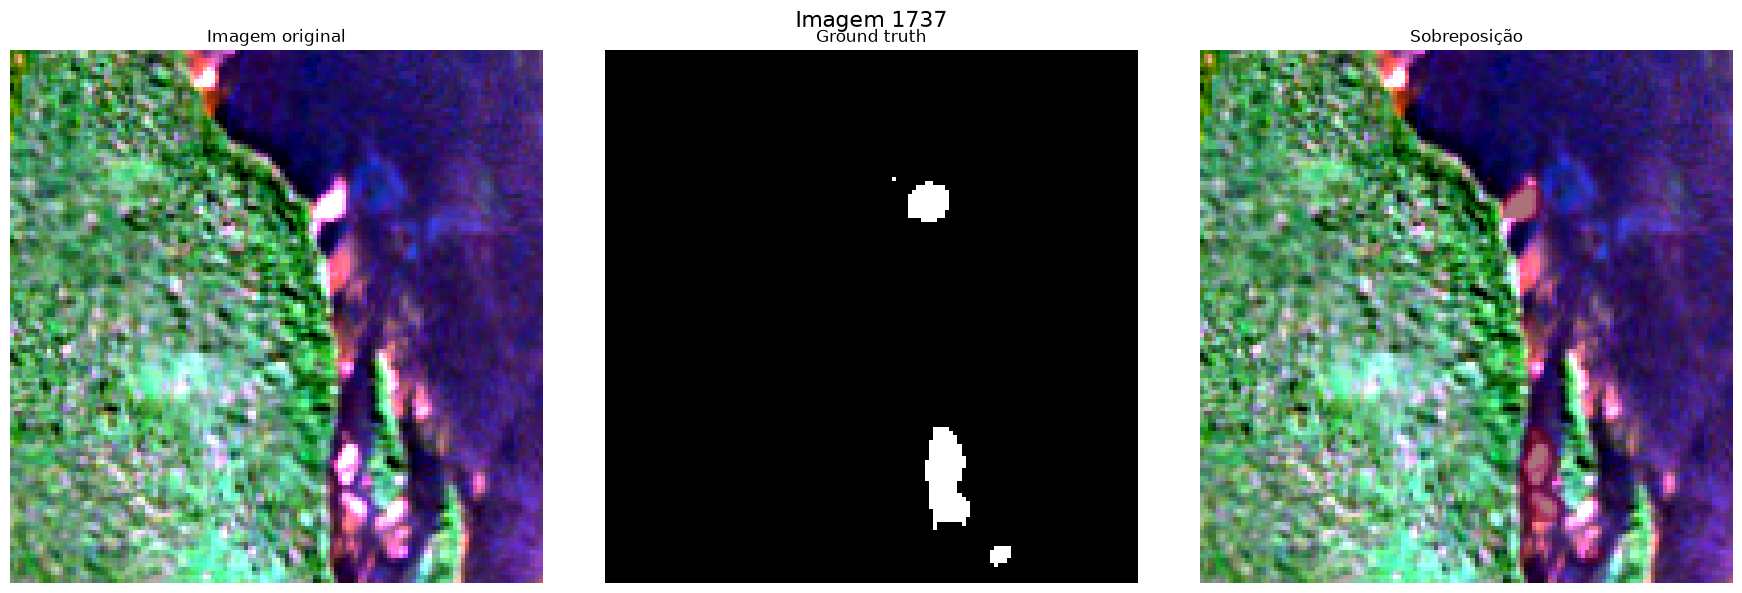

In [44]:
resultado = gerar_mascara_final(
    ID_IMAGEM,
    all_touched=True
)

mascara_final = resultado[
    "mascara"
]

print(
    f"Imagem: {resultado['imagem']}"
)

print(
    f"Vetor: {resultado['vetor']}"
)

print(
    f"Máscara salva em: {resultado['saida']}"
)

print()
print(
    "Shape:",
    mascara_final.shape
)

print(
    "Tipo:",
    mascara_final.dtype
)

print(
    "Valores únicos:",
    np.unique(mascara_final)
)

pixels_positivos = int(
    np.sum(
        mascara_final == 255
    )
)

pixels_totais = int(
    mascara_final.size
)

percentual = (
    100
    * pixels_positivos
    / pixels_totais
)

print(
    "Pixels positivos:",
    pixels_positivos
)

print(
    "Percentual positivo:",
    f"{percentual:.3f}%"
)

visualizar_resultado(
    resultado["imagem"],
    mascara_final,
    titulo=f"Imagem {ID_IMAGEM}"
)


## Observação

Se a máscara parecer um pouco maior do que o polígono desenhado no QGIS, isso pode ocorrer porque `all_touched=True` marca todo pixel tocado pelo polígono.

Para usar apenas pixels cujo centro está dentro do polígono, troque na última célula:

```python
all_touched=False
```

Para este projeto, `True` é útil quando se prefere preservar regiões finas do banco de areia durante a rasterização.
